# Step 12 -- Lid-Driven Cavity Flow

The [lid-driven cavity](https://en.wikipedia.org/wiki/Lid_driven_cavity_problem) is the canonical benchmark for 2D incompressible Navier--Stokes solvers.  A square box has no-slip walls on all four sides, with the top lid sliding at constant velocity $u_{\text{lid}} = 1$.

**PDE -- vorticity-streamfunction formulation:**

$$
\frac{\partial \omega}{\partial t}
+ u\frac{\partial \omega}{\partial x}
+ v\frac{\partial \omega}{\partial y}
= \nu\,\nabla^2 \omega
$$

$$
\nabla^2 \psi = -\omega, \qquad
u = \frac{\partial \psi}{\partial y}, \qquad
v = -\frac{\partial \psi}{\partial x}
$$

At each time step we:

1. Invert the Poisson equation $\nabla^2\psi = -\omega$ to get the streamfunction (Step 10 solver)
2. Compute velocity from $\psi$
3. Advect and diffuse $\omega$
4. Apply wall BCs (Thom's formula for wall vorticity)

The Reynolds number is $Re = u_{\text{lid}} L / \nu$.  At $Re = 100$ the flow is steady and well-characterised by the Ghia et al. (1982) benchmark data.

**What you will learn:**

1. How to set up and integrate a Navier--Stokes model in somax
2. How to recover velocity and streamfunction via `model.diagnose()`
3. How to compare against the Ghia benchmark

## Arakawa C-Grid and Boundary Conditions

The vorticity $\omega$ and streamfunction $\psi$ live at cell centres on the Arakawa C-grid, while velocity components sit on cell faces:

```
       V_{j+1/2}
    ┌─────●─────┐
    │           │
 U  ●     T     ●  U
i-1/2   (i,j)    i+1/2
    │           │
    └─────●─────┘
       V_{j-1/2}
```

**Lid-driven cavity BCs**:

```
             u_lid = 1  (moving lid)
        ┌──────────────────────┐
        │                      │
 u=0    │    omega, psi        │  u=0
 v=0    │    (interior)        │  v=0
        │                      │
        └──────────────────────┘
             u=0, v=0  (no-slip)
```

At walls, vorticity is computed via **Thom's formula**:

$$\omega_{wall} = -\frac{2(\psi_{interior} - \psi_{wall})}{\Delta n^2}$$

At the top lid (moving at $u_{lid}$), an extra term accounts for the wall velocity:

$$\omega_{top} = -\frac{2\psi_{interior}}{\Delta y^2} - \frac{2 u_{lid}}{\Delta y}$$

In [1]:
from __future__ import annotations

import diffrax as dfx
import equinox as eqx
import jax.numpy as jnp
import matplotlib.pyplot as plt

from somax.models import IncompressibleNS2D, NSVorticityState

## 1. Create the model

We use a 64x64 grid with $\nu = 0.01$ ($Re = 100$).

In [2]:
nx, ny = 32, 32
nu = 0.05
model = IncompressibleNS2D.create(
    nx=nx, ny=ny, Lx=1.0, Ly=1.0, nu=nu, problem="cavity", u_lid=1.0
)
Re = 1.0 / nu
print(f"Grid: {model.grid.Ny} x {model.grid.Nx} (including ghost cells)")
print(f"dx = {model.grid.dx:.4f}, dy = {model.grid.dy:.4f}")
print(f"Re = {Re:.0f}")

Grid: 34 x 34 (including ghost cells)
dx = 0.0312, dy = 0.0312
Re = 20


## 2. Initial condition and integration

Start from rest ($\omega = 0$ everywhere) and integrate until the flow reaches a statistical steady state.  At $Re = 100$ the flow converges within $t \approx 5$--$10$.

We use the default `Tsit5()` solver with a small time step for stability of the explicit advection.

In [3]:
state0 = NSVorticityState(omega=jnp.zeros((model.grid.Ny, model.grid.Nx)))

sol = model.integrate(
    state0,
    t0=0.0,
    t1=2.0,
    dt=0.001,
    saveat=dfx.SaveAt(t1=True),
)

omega_final = sol.ys.omega[0]
print(
    f"Final omega range: [{float(jnp.min(omega_final)):.4f},"
    f" {float(jnp.max(omega_final)):.4f}]"
)
print(f"All finite: {bool(jnp.all(jnp.isfinite(omega_final)))}")

Final omega range: [-64.0000, 7.1936]
All finite: True


## 3. Diagnostics: velocity and streamfunction

`model.diagnose()` recovers the streamfunction $\psi$ and velocity components $(u, v)$ from the vorticity field, along with kinetic energy and enstrophy.

In [4]:
state_final = NSVorticityState(omega=omega_final)
diag = model.diagnose(state_final)

print(f"Kinetic energy: {float(diag.kinetic_energy):.6f}")
print(f"Enstrophy:      {float(diag.enstrophy):.6f}")

Kinetic energy: 0.008409
Enstrophy:      0.500323


## 4. Visualise the flow

We plot the vorticity field and streamfunction contours.

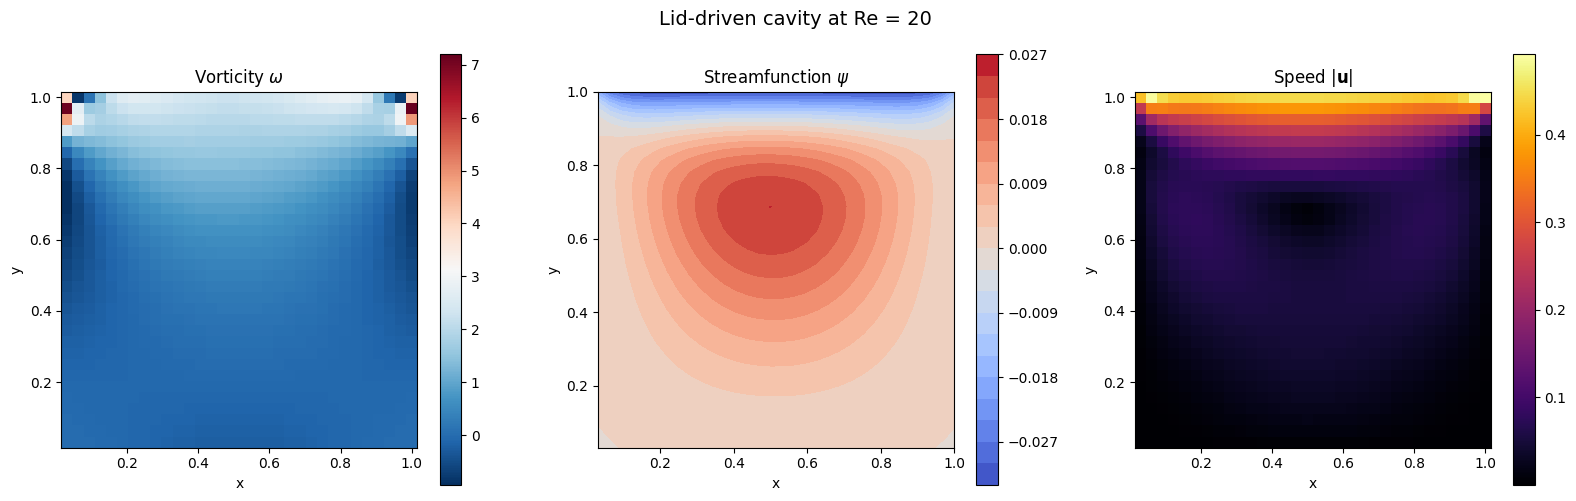

In [5]:
x = jnp.arange(model.grid.Nx) * model.grid.dx
y = jnp.arange(model.grid.Ny) * model.grid.dy
X, Y = jnp.meshgrid(x, y)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Vorticity
im0 = axes[0].pcolormesh(
    X[1:-1, 1:-1],
    Y[1:-1, 1:-1],
    omega_final[1:-1, 1:-1],
    shading="auto",
    cmap="RdBu_r",
)
axes[0].set_title(r"Vorticity $\omega$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
plt.colorbar(im0, ax=axes[0])

# Streamfunction
im1 = axes[1].contourf(
    X[1:-1, 1:-1],
    Y[1:-1, 1:-1],
    diag.psi[1:-1, 1:-1],
    levels=20,
    cmap="coolwarm",
)
axes[1].set_title(r"Streamfunction $\psi$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")
plt.colorbar(im1, ax=axes[1])

# Velocity magnitude
speed = jnp.sqrt(diag.u**2 + diag.v**2)
im2 = axes[2].pcolormesh(
    X[1:-1, 1:-1],
    Y[1:-1, 1:-1],
    speed[1:-1, 1:-1],
    shading="auto",
    cmap="inferno",
)
axes[2].set_title("Speed $|\\mathbf{u}|$")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_aspect("equal")
plt.colorbar(im2, ax=axes[2])

plt.suptitle(f"Lid-driven cavity at Re = {Re:.0f}", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Ghia benchmark comparison

Ghia, Ghia & Shin (1982) tabulated centreline velocity profiles for the lid-driven cavity at various Reynolds numbers.  The data for $Re = 100$ is bundled in somax.

We extract:
- $u$-velocity along the vertical centreline ($x = 0.5$)
- $v$-velocity along the horizontal centreline ($y = 0.5$)

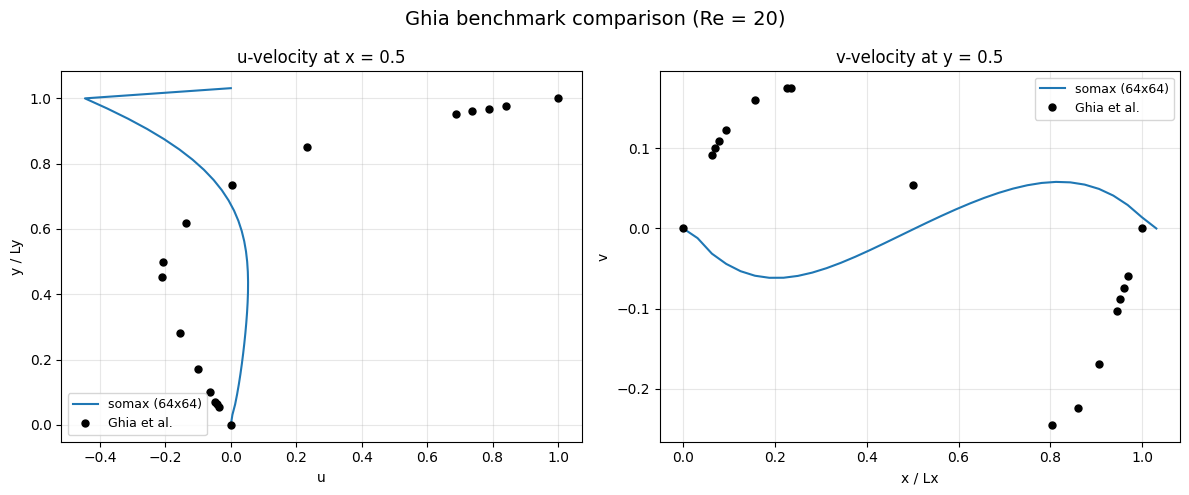

In [6]:
from somax._src.models.pde2d.navier_stokes import (
    GHIA_RE100_U,
    GHIA_RE100_V,
    GHIA_RE100_X,
    GHIA_RE100_Y,
)


# Centreline indices
mid_i = model.grid.Nx // 2  # x = 0.5
mid_j = model.grid.Ny // 2  # y = 0.5

# Normalised coordinates (interior only)
y_norm = y / model.grid.Ly
x_norm = x / model.grid.Lx

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# u along vertical centreline
ax = axes[0]
ax.plot(diag.u[:, mid_i], y_norm, "-", lw=1.5, label="somax (64x64)")
ax.plot(GHIA_RE100_U, GHIA_RE100_Y, "ko", markersize=5, label="Ghia et al.")
ax.set_xlabel("u")
ax.set_ylabel("y / Ly")
ax.set_title("u-velocity at x = 0.5")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# v along horizontal centreline
ax = axes[1]
ax.plot(x_norm, diag.v[mid_j, :], "-", lw=1.5, label="somax (64x64)")
ax.plot(GHIA_RE100_X, GHIA_RE100_V, "ko", markersize=5, label="Ghia et al.")
ax.set_xlabel("x / Lx")
ax.set_ylabel("v")
ax.set_title("v-velocity at y = 0.5")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(f"Ghia benchmark comparison (Re = {Re:.0f})", fontsize=14)
plt.tight_layout()
plt.show()

At 64x64 the agreement is qualitatively good but not pixel-perfect. The overall shape -- the primary vortex, wall jets, and centreline profiles -- matches the benchmark.  Higher resolution (128x128 or 256x256) and/or higher-order advection schemes would improve the match.

## 6. Vorticity-streamfunction formulation: why?

The vorticity-streamfunction form eliminates pressure entirely. In the primitive-variable form ($u, v, p$), one must solve a pressure Poisson equation to enforce $\nabla \cdot \mathbf{u} = 0$. In the vorticity form, the divergence-free constraint is built in: any velocity derived from a streamfunction is automatically divergence-free.

The trade-off: we must still solve a Poisson equation (for $\psi$ from $\omega$), but there is no pressure variable at all.  This simplifies the numerics significantly for 2D flows.

## 7. Differentiability -- gradient through the NS solver

We compute $\partial \mathcal{E} / \partial \nu$ where $\mathcal{E}$ is the final enstrophy. This gradient tells us how viscosity affects the flow at steady state.

In [7]:
@eqx.filter_grad
def grad_enstrophy_wrt_model(m):
    s0 = NSVorticityState(omega=jnp.zeros((m.grid.Ny, m.grid.Nx)))
    sol = m.integrate(s0, t0=0.0, t1=0.5, dt=0.001, saveat=dfx.SaveAt(t1=True))
    final = NSVorticityState(omega=sol.ys.omega[0])
    return m.diagnose(final).enstrophy


grads = grad_enstrophy_wrt_model(model)
print(f"dEnstrophy/dnu = {float(grads.params.nu):.6f}")

dEnstrophy/dnu = -0.305957


## Summary

| Concept | API |
|---------|-----|
| Create NS model | `IncompressibleNS2D.create(nx, ny, nu, problem="cavity")` |
| Initial state | `NSVorticityState(omega=jnp.zeros(...))` |
| Integrate | `model.integrate(state0, t0, t1, dt, saveat=...)` |
| Recover velocity | `model.diagnose(state)` returns $\psi, u, v, KE$ |
| Ghia data | `GHIA_RE100_Y`, `GHIA_RE100_U`, etc. |

**Next:** [Step 13](step13_channel_flow) applies the same solver to pressure-driven channel (Poiseuille) flow with an analytical solution and demonstrates differentiating through the simulation.